# Strava Data Exploratory Analysis

Initial data review and descriptive statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import json
from pathlib import Path

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print('✅ Libraries imported')

✅ Libraries imported


## 1. Load Data

In [2]:
# Find the latest exported file
data_dir = Path('../data/raw')
json_files = sorted(data_dir.glob('activities_*.json'), reverse=True)

if not json_files:
    print("❌ No activity files found. Run strava_export.py first.")
else:
    latest_file = json_files[0]
    print(f"📂 Loading: {latest_file.name}")
    
    with open(latest_file) as f:
        activities_raw = json.load(f)
    
    # Convert to DataFrame
    df = pd.DataFrame(activities_raw)
    
    # Convert date columns
    df['start_date'] = pd.to_datetime(df['start_date'])
    
    print(f"\n✅ Loaded {len(df)} activities")
    print(f"Date range: {df['start_date'].min().date()} to {df['start_date'].max().date()}")
    print(f"\nColumns: {df.shape[1]}")
    print(df.columns.tolist())

📂 Loading: activities_20260326_131148.json

✅ Loaded 1651 activities
Date range: 2016-06-20 to 2026-03-25

Columns: 17
['id', 'name', 'type', 'sport_type', 'start_date', 'distance_m', 'duration_s', 'elevation_m', 'average_speed_ms', 'max_speed_ms', 'average_hr', 'max_hr', 'average_watts', 'kilojoules', 'calories', 'device_name', 'visibility']


## 2. Data Overview

In [3]:
print("\n📊 First few rows:")
print(df.head())


📊 First few rows:
            id           name type sport_type                start_date  \
0  17855245023      Lunch Run  Run        Run 2026-03-25 16:14:09+00:00   
1  17847315917    Evening Run  Run        Run 2026-03-24 22:25:58+00:00   
2  17832831839  Afternoon Run  Run        Run 2026-03-23 20:44:39+00:00   
3  17816254075    Morning Run  Run        Run 2026-03-22 12:16:06+00:00   
4  17804986131    Morning Run  Run        Run 2026-03-21 14:45:38+00:00   

   distance_m  duration_s  elevation_m  average_speed_ms  max_speed_ms  \
0      5879.7        1887         34.8             3.116          5.42   
1      8594.0        2848         34.6             3.018          4.18   
2      4088.4        1330         13.8             3.074          4.26   
3     13623.1        4367        117.2             3.120          6.02   
4      9689.2        3144         74.8             3.082          4.60   

   average_hr  max_hr  average_watts  kilojoules calories  \
0       171.8   182.0   

In [4]:
print("\n📈 Data types & missing values:")
print(df.info())


📈 Data types & missing values:
<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                1651 non-null   int64              
 1   name              1651 non-null   str                
 2   type              1651 non-null   str                
 3   sport_type        1651 non-null   str                
 4   start_date        1651 non-null   datetime64[us, UTC]
 5   distance_m        1651 non-null   float64            
 6   duration_s        1651 non-null   int64              
 7   elevation_m       1651 non-null   float64            
 8   average_speed_ms  1651 non-null   float64            
 9   max_speed_ms      1651 non-null   float64            
 10  average_hr        1311 non-null   float64            
 11  max_hr            1311 non-null   float64            
 12  average_watts     1213 non-null   float64

In [5]:
print("\n🔢 Descriptive statistics:")
print(df.describe())


🔢 Descriptive statistics:
                 id     distance_m    duration_s  elevation_m  \
count  1.651000e+03    1651.000000   1651.000000  1651.000000   
mean   8.423249e+09   26270.171714   4215.797093   298.890067   
std    4.487173e+09   19131.823637   2705.926610   282.739865   
min    6.156769e+08       0.000000     82.000000     0.000000   
25%    4.554593e+09   10581.200000   2730.500000   106.050000   
50%    7.985049e+09   24972.500000   3621.000000   218.000000   
75%    1.168085e+10   33993.250000   5008.500000   410.200000   
max    1.785525e+10  163394.000000  29551.000000  2278.000000   

       average_speed_ms  max_speed_ms   average_hr       max_hr  \
count       1651.000000   1651.000000  1311.000000  1311.000000   
mean           6.085761     13.088409   154.032647   175.810831   
std            2.345536      5.314548    13.360545    11.532334   
min            0.000000      0.000000    91.000000   113.000000   
25%            3.307500      8.100000   147.000000  

## 3. Activity Type Distribution


🏃 Activity Types:
type
Ride              745
Run               494
VirtualRide       388
Hike               15
Walk                6
BackcountrySki      2
Workout             1
Name: count, dtype: int64


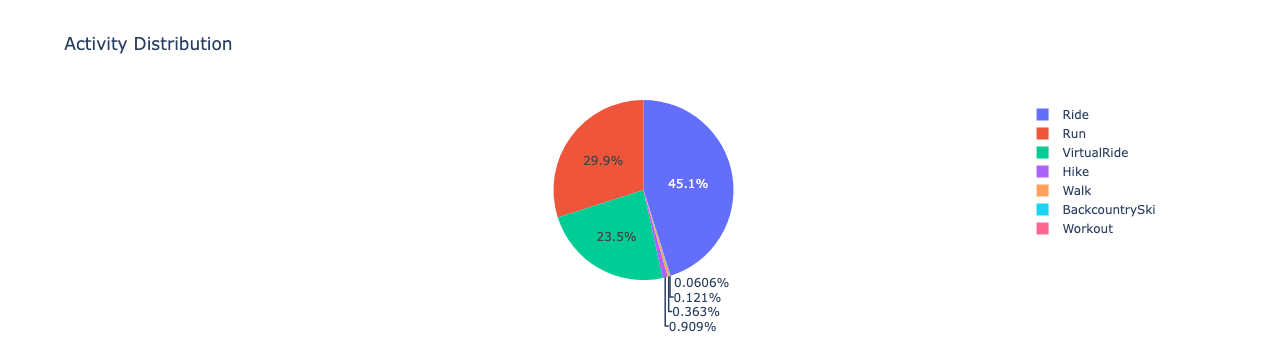

In [6]:
# Activity types
activity_counts = df['type'].value_counts()
print("\n🏃 Activity Types:")
print(activity_counts)

fig = px.pie(names=activity_counts.index, values=activity_counts.values, 
             title='Activity Distribution')
fig.show()

## 4. Volume Trends Over Time

/tmp/ipykernel_32491/1054535682.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['start_date'].dt.to_period('M')


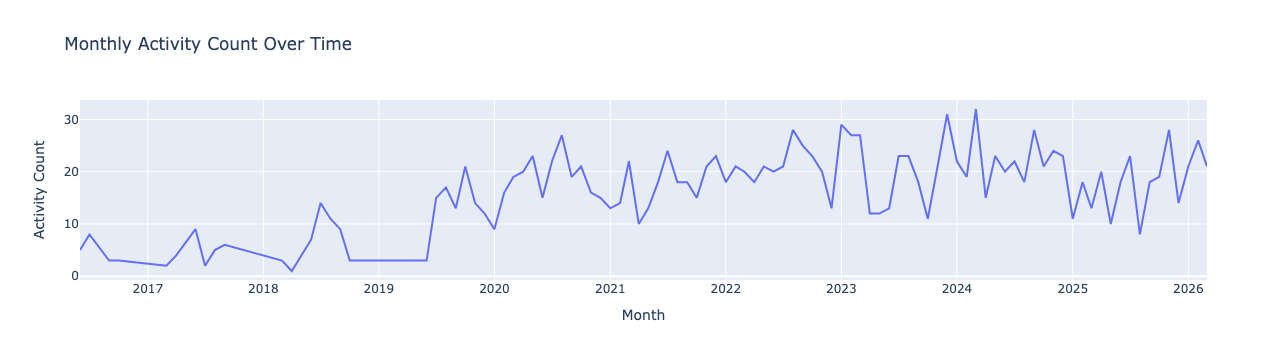


Monthly activity stats:
Mean: 16.7
Median: 18.0
Max: 32
Min: 1


In [7]:
# Add time features
df['year'] = df['start_date'].dt.year
df['month'] = df['start_date'].dt.month
df['week'] = df['start_date'].dt.isocalendar().week
df['day_of_week'] = df['start_date'].dt.day_name()
df['date_only'] = df['start_date'].dt.date

# Monthly activity count
df['year_month'] = df['start_date'].dt.to_period('M')
monthly_activity = df.groupby('year_month').size()

fig = px.line(x=monthly_activity.index.astype(str), y=monthly_activity.values,
              labels={'x': 'Month', 'y': 'Activity Count'},
              title='Monthly Activity Count Over Time')
fig.show()

print(f"\nMonthly activity stats:")
print(f"Mean: {monthly_activity.mean():.1f}")
print(f"Median: {monthly_activity.median():.1f}")
print(f"Max: {monthly_activity.max()}")
print(f"Min: {monthly_activity.min()}")

## 5. Distance & Duration Analysis

In [8]:
# Convert to more readable units
df['distance_km'] = df['distance_m'] / 1000
df['duration_hours'] = df['duration_s'] / 3600
df['pace_kmh'] = df['distance_km'] / df['duration_hours']

print("\n📏 Distance (km):")
print(df['distance_km'].describe())

print("\n⏱️ Duration (hours):")
print(df['duration_hours'].describe())

print("\n🏃 Pace (km/h):")
print(df['pace_kmh'].describe())


📏 Distance (km):
count    1651.000000
mean       26.270172
std        19.131824
min         0.000000
25%        10.581200
50%        24.972500
75%        33.993250
max       163.394000
Name: distance_km, dtype: float64

⏱️ Duration (hours):
count    1651.000000
mean        1.171055
std         0.751646
min         0.022778
25%         0.758472
50%         1.005833
75%         1.391250
max         8.208611
Name: duration_hours, dtype: float64

🏃 Pace (km/h):
count    1651.000000
mean       21.908749
std         8.443976
min         0.000000
25%        11.907678
50%        24.227494
75%        28.634351
max        40.731740
Name: pace_kmh, dtype: float64


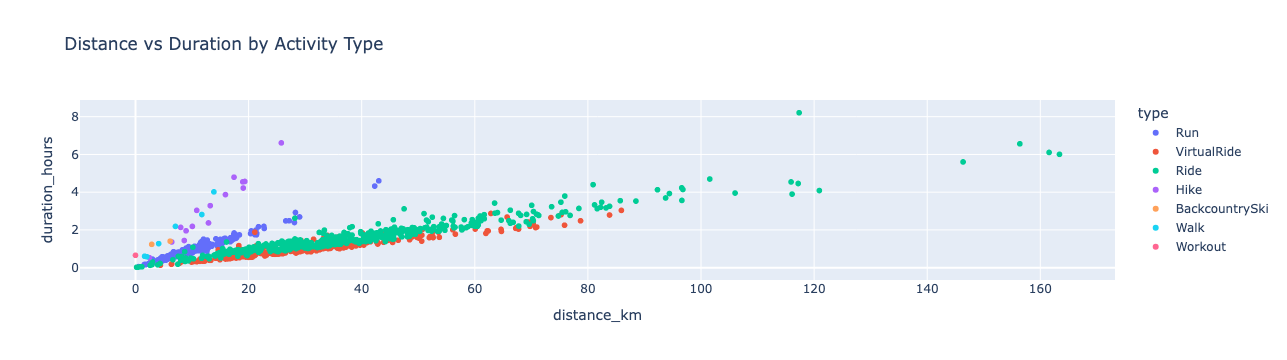

In [9]:
# Scatter: distance vs duration
fig = px.scatter(df, x='distance_km', y='duration_hours', color='type',
                 hover_data=['name', 'start_date'],
                 title='Distance vs Duration by Activity Type')
fig.show()

## 6. Heart Rate Analysis

In [10]:
# Filter activities with HR data
df_with_hr = df[df['average_hr'].notna()]

print(f"\n❤️ Activities with HR data: {len(df_with_hr)} / {len(df)} ({len(df_with_hr)/len(df)*100:.1f}%)")
print("\nAverage Heart Rate:")
print(df_with_hr['average_hr'].describe())

print("\nMax Heart Rate:")
print(df_with_hr['max_hr'].describe())


❤️ Activities with HR data: 1311 / 1651 (79.4%)

Average Heart Rate:
count    1311.000000
mean      154.032647
std        13.360545
min        91.000000
25%       147.000000
50%       154.800000
75%       162.600000
max       185.200000
Name: average_hr, dtype: float64

Max Heart Rate:
count    1311.000000
mean      175.810831
std        11.532334
min       113.000000
25%       169.000000
50%       178.000000
75%       184.000000
max       244.000000
Name: max_hr, dtype: float64


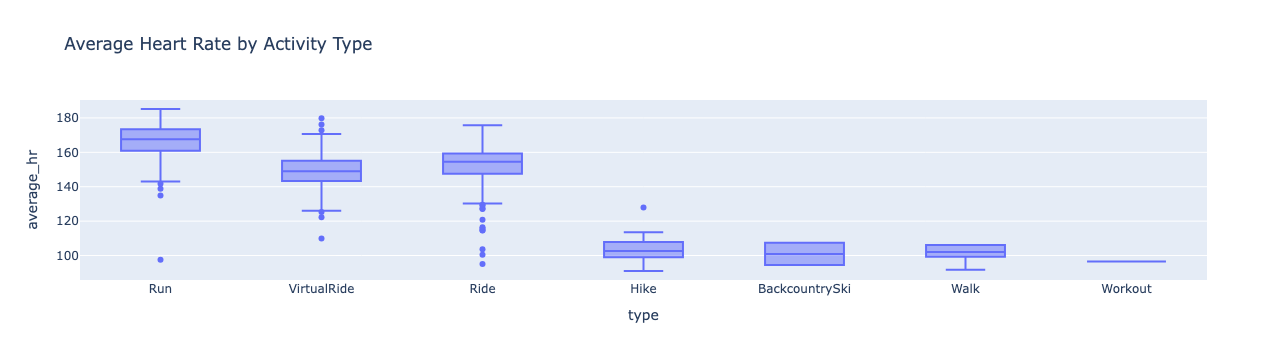

In [11]:
# HR distribution by activity type
fig = px.box(df_with_hr, x='type', y='average_hr',
            title='Average Heart Rate by Activity Type')
fig.show()

## 7. Elevation & Power Analysis

In [12]:
print("\n⛰️ Elevation Gain (m):")
print(df['elevation_m'].describe())

df_with_power = df[df['average_watts'].notna()]
print(f"\n⚡ Activities with power data: {len(df_with_power)} / {len(df)} ({len(df_with_power)/len(df)*100:.1f}%)")

if len(df_with_power) > 0:
    print("\nAverage Power (W):")
    print(df_with_power['average_watts'].describe())


⛰️ Elevation Gain (m):
count    1651.000000
mean      298.890067
std       282.739865
min         0.000000
25%       106.050000
50%       218.000000
75%       410.200000
max      2278.000000
Name: elevation_m, dtype: float64

⚡ Activities with power data: 1213 / 1651 (73.5%)

Average Power (W):
count    1213.000000
mean      142.854328
std        24.088351
min        52.000000
25%       131.600000
50%       145.900000
75%       155.900000
max       208.300000
Name: average_watts, dtype: float64


## 8. Consistency Analysis

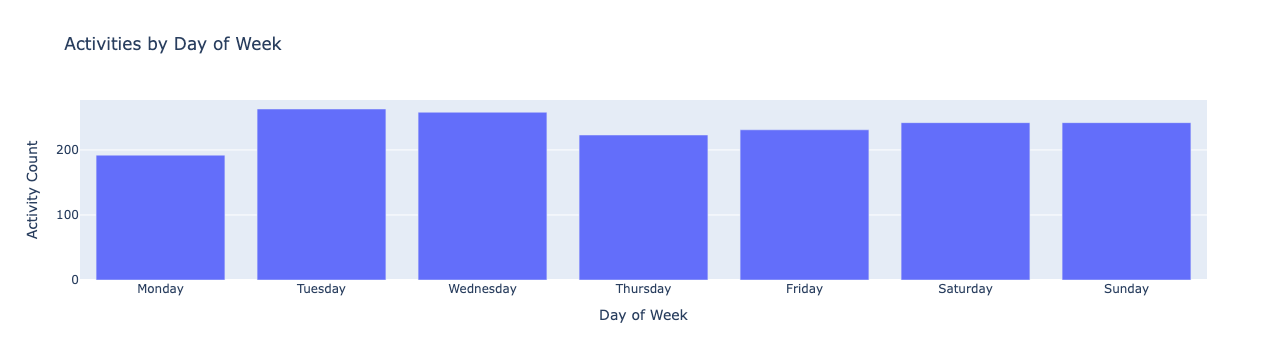


📅 Activity Distribution by Day:
day_of_week
Monday       192
Tuesday      263
Wednesday    258
Thursday     223
Friday       231
Saturday     242
Sunday       242
Name: count, dtype: int64


In [13]:
# Activities per day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(dow_order)

fig = px.bar(x=dow_counts.index, y=dow_counts.values,
            labels={'x': 'Day of Week', 'y': 'Activity Count'},
            title='Activities by Day of Week')
fig.show()

print("\n📅 Activity Distribution by Day:")
print(dow_counts)

In [14]:
# Weeks without activity (gaps)
df_sorted = df.sort_values('start_date')
df_sorted['date_only'] = df_sorted['start_date'].dt.date
unique_dates = df_sorted['date_only'].unique()

# Find gaps
gaps = []
for i in range(len(unique_dates)-1):
    gap = (unique_dates[i+1] - unique_dates[i]).days
    if gap > 7:  # Only gaps > 1 week
        gaps.append(gap)

if gaps:
    print(f"\n🔍 Long gaps (> 7 days):")
    print(f"Number of gaps: {len(gaps)}")
    print(f"Average gap: {np.mean(gaps):.0f} days")
    print(f"Max gap: {np.max(gaps)} days")
    print(f"Min gap: {np.min(gaps)} days")
else:
    print("\n✅ No long gaps detected")


🔍 Long gaps (> 7 days):
Number of gaps: 38
Average gap: 31 days
Max gap: 251 days
Min gap: 8 days


## 9. Personal Records (PRs)

In [15]:
print("\n🏆 Personal Records:")
print(f"Longest distance: {df['distance_km'].max():.2f} km")
print(f"Longest duration: {df['duration_hours'].max():.2f} hours")
print(f"Highest elevation: {df['elevation_m'].max():.0f} m")
if len(df_with_hr) > 0:
    print(f"Highest avg HR: {df_with_hr['average_hr'].max():.0f} bpm")
    print(f"Highest max HR: {df_with_hr['max_hr'].max():.0f} bpm")
if len(df_with_power) > 0:
    print(f"Highest avg power: {df_with_power['average_watts'].max():.0f} W")


🏆 Personal Records:
Longest distance: 163.39 km
Longest duration: 8.21 hours
Highest elevation: 2278 m
Highest avg HR: 185 bpm
Highest max HR: 244 bpm
Highest avg power: 208 W


## 10. Heatmap: Activity Intensity by Month/Year

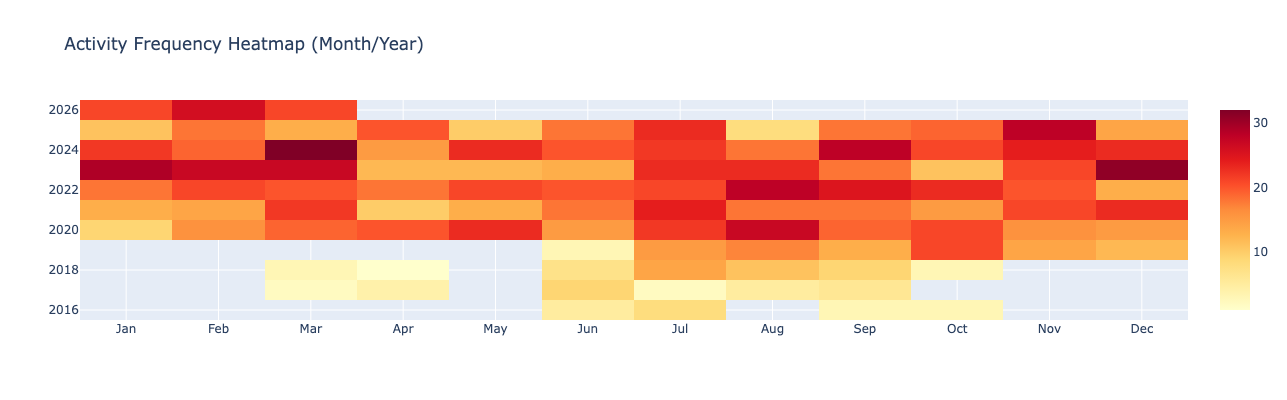

In [16]:
# Create a pivot table for heatmap
df['year_month_str'] = df['start_date'].dt.strftime('%Y-%m')
activity_heatmap = df.groupby(['year', 'month']).size().reset_index(name='count')

# Convert to pivot
pivot_data = activity_heatmap.pivot(index='year', columns='month', values='count')

fig = go.Figure(data=go.Heatmap(
    z=pivot_data.values,
    x=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    y=pivot_data.index,
    colorscale='YlOrRd'
))
fig.update_layout(title='Activity Frequency Heatmap (Month/Year)', height=400)
fig.show()

## 11. Summary

In [17]:
print("\n" + "="*60)
print("📊 DATA SUMMARY")
print("="*60)
print(f"Total activities: {len(df)}")
print(f"Date range: {df['start_date'].min().date()} to {df['start_date'].max().date()}")
print(f"Total distance: {df['distance_km'].sum():.0f} km")
print(f"Total duration: {df['duration_hours'].sum():.0f} hours")
print(f"Activity types: {', '.join(activity_counts.index.tolist())}")
print(f"\nHR data: {len(df_with_hr)} activities ({len(df_with_hr)/len(df)*100:.1f}%)")
print(f"Power data: {len(df_with_power)} activities ({len(df_with_power)/len(df)*100:.1f}%)")
print("="*60)


📊 DATA SUMMARY
Total activities: 1651
Date range: 2016-06-20 to 2026-03-25
Total distance: 43372 km
Total duration: 1933 hours
Activity types: Ride, Run, VirtualRide, Hike, Walk, BackcountrySki, Workout

HR data: 1311 activities (79.4%)
Power data: 1213 activities (73.5%)


## Next Steps

1. **02_hypothesis_testing.ipynb** — Test fitness improvement over time, correlations, etc.
2. **03_biometric_correlation.ipynb** — Merge with Apple Watch / Garmin data
3. **Model comparison** — Run same analyses across Haiku 4.5, Sonnet 4.6, Kimi 2.5